# Q5: Price vs Affordability Sensitivity Analysis
**CarIQ Capstone — Phase 4 EDA**

## Business Question
How does a ±10% change in vehicle price affect the pool of eligible
buyers across income segments?

## Methodology
- Baseline: current vehicle prices from master dataset
- Scenario A: prices reduced by 10% (price_usd_equivalent × 0.90)
- Scenario B: prices increased by 10% (price_usd_equivalent × 1.10)
- For each scenario, recompute loan_amount and EMI using locked formula
- Count eligible buyers where new EMI ≤ 40% of monthly_income_usd
- Compare eligible buyer pool across all three scenarios by segment

## Data Source
- `analytics/data/master.csv` — loan transactions with income + price data
- EMI formula: P × r × (1+r)^n / ((1+r)^n − 1)

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.2f}'.format)
print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
master = pd.read_csv('../data/master.csv')
loans  = master[master['payment_mode'] == 'Loan'].copy()

print(f"Loan transactions for sensitivity analysis: {len(loans)}")
print(f"\nBaseline statistics:")
print(f"  Avg vehicle price (USD) : ${loans['price_usd_equivalent'].mean():>10,.0f}")
print(f"  Avg EMI (USD)           : ${loans['emi_amount_usd'].mean():>10,.2f}")
print(f"  Avg monthly income (USD): ${loans['monthly_income_usd'].mean():>10,.2f}")
print(f"  Affordable (baseline)   : {loans['is_affordable'].sum()} / {len(loans)}")

Loan transactions for sensitivity analysis: 60

Baseline statistics:
  Avg vehicle price (USD) : $   288,927
  Avg EMI (USD)           : $  5,907.46
  Avg monthly income (USD): $  3,270.21
  Affordable (baseline)   : 33 / 60


In [3]:
# EMI formula — mirrors the Node.js emiCalculator.js implementation
def calculate_emi(principal, annual_rate, tenure_months):
    if pd.isna(principal) or pd.isna(annual_rate) or pd.isna(tenure_months):
        return np.nan
    r = annual_rate / 12 / 100
    n = int(tenure_months)
    if r == 0:
        return principal / n
    return round(principal * r * (1 + r)**n / ((1 + r)**n - 1), 2)

# Verify against known benchmark
test_emi = calculate_emi(500000, 9.5, 60)
print(f"EMI verification: ₹5L at 9.5% for 60mo = ₹{test_emi:,.2f}")
print(f"Expected: ~₹10,500 ✅" if 10400 < test_emi < 10600 else "❌ Check formula")

EMI verification: ₹5L at 9.5% for 60mo = ₹10,500.93
Expected: ~₹10,500 ✅


In [4]:
INR_TO_USD = 0.0107

def run_scenario(df, price_adjustment, label):
    scenario = df.copy()

    # Adjust price
    scenario['adj_price_usd'] = (
        scenario['price_usd_equivalent'] * price_adjustment
    )

    # Recompute loan amount (preserve same down-payment ratio)
    orig_down_pct = 1 - (
        scenario['loan_amount'] / (scenario['final_price_inr'])
    ).clip(0, 1)
    scenario['adj_loan_usd'] = (
        scenario['adj_price_usd'] * (1 - orig_down_pct)
    )

    # Convert loan to INR for EMI calculation (EMI stored in INR)
    scenario['adj_loan_inr'] = scenario['adj_loan_usd'] / INR_TO_USD

    # Recompute EMI
    scenario['adj_emi_inr'] = scenario.apply(
        lambda r: calculate_emi(
            r['adj_loan_inr'],
            r['interest_rate'],
            r['loan_tenure_months']
        ), axis=1
    )

    # Convert EMI to USD
    scenario['adj_emi_usd'] = scenario['adj_emi_inr'] * INR_TO_USD

    # Recompute affordability
    scenario['adj_ratio']      = scenario['adj_emi_usd'] / scenario['monthly_income_usd']
    scenario['adj_affordable'] = (scenario['adj_ratio'] <= 0.40).astype(int)
    scenario['scenario']       = label

    return scenario


baseline   = run_scenario(loans, 1.00, 'Baseline (0%)')
minus_10   = run_scenario(loans, 0.90, 'Price −10%')
plus_10    = run_scenario(loans, 1.10, 'Price +10%')

# Summary
for s in [baseline, minus_10, plus_10]:
    eligible = s['adj_affordable'].sum()
    total    = len(s)
    avg_emi  = s['adj_emi_usd'].mean()
    print(f"{s['scenario'].iloc[0]:<20} : "
          f"{eligible}/{total} eligible ({eligible/total*100:.0f}%) | "
          f"Avg EMI: ${avg_emi:,.2f}")

Baseline (0%)        : 33/60 eligible (55%) | Avg EMI: $5,907.46
Price −10%           : 34/60 eligible (57%) | Avg EMI: $5,316.71
Price +10%           : 33/60 eligible (55%) | Avg EMI: $6,498.21


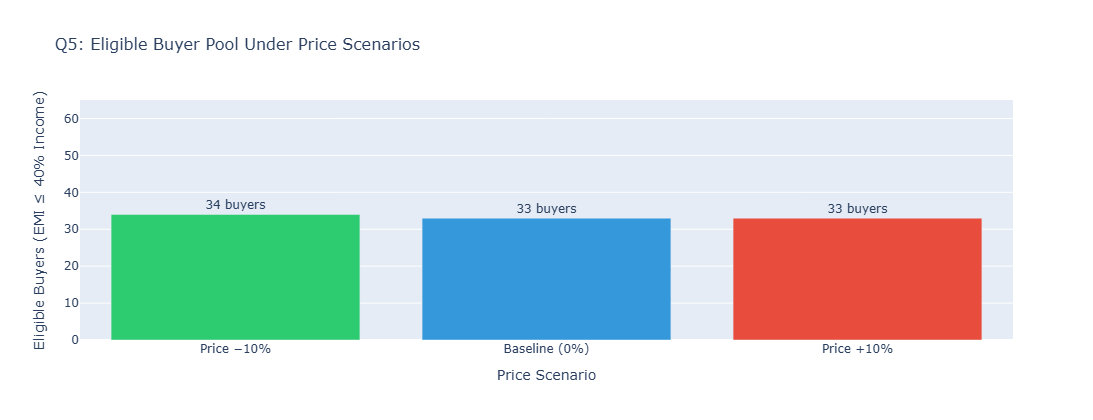

In [5]:
scenarios = ['Price −10%', 'Baseline (0%)', 'Price +10%']
eligible  = [
    minus_10['adj_affordable'].sum(),
    baseline['adj_affordable'].sum(),
    plus_10['adj_affordable'].sum()
]
colors = ['#2ecc71', '#3498db', '#e74c3c']

fig1 = go.Figure(go.Bar(
    x=scenarios,
    y=eligible,
    marker_color=colors,
    text=eligible,
    textposition='outside',
    texttemplate='%{text} buyers'
))

fig1.update_layout(
    title='Q5: Eligible Buyer Pool Under Price Scenarios',
    xaxis_title='Price Scenario',
    yaxis_title='Eligible Buyers (EMI ≤ 40% Income)',
    yaxis=dict(range=[0, len(loans) + 5]),
    height=420,
    title_font_size=16
)
fig1.show()

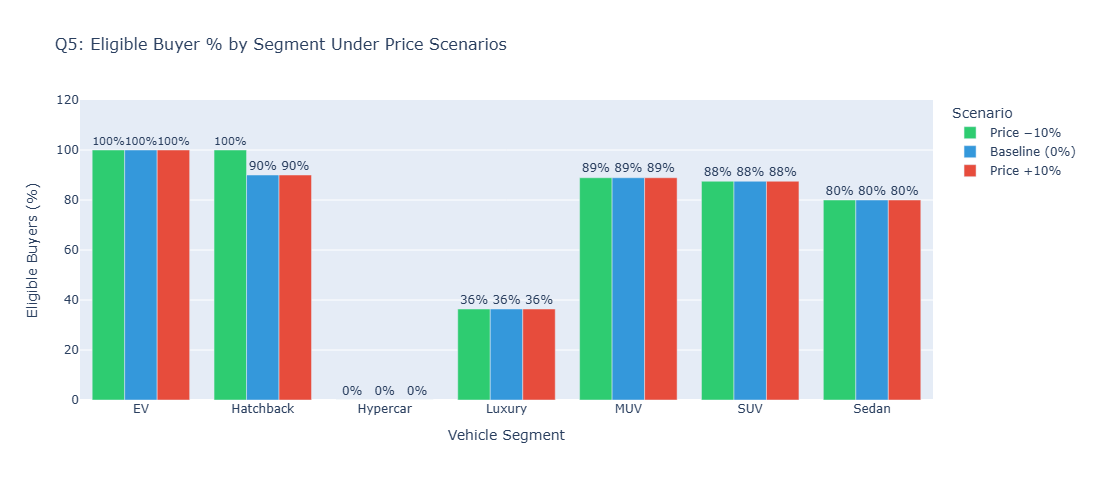


── Segment Eligibility by Scenario ──
scenario   Baseline (0%)  Price +10%  Price −10%
segment                                         
EV                100.00      100.00      100.00
Hatchback          90.00       90.00      100.00
Hypercar            0.00        0.00        0.00
Luxury             36.40       36.40       36.40
MUV                88.90       88.90       88.90
SUV                87.50       87.50       87.50
Sedan              80.00       80.00       80.00


In [6]:
def segment_eligibility(df, label):
    seg = df.groupby('segment').agg(
        total      = ('adj_affordable', 'count'),
        eligible   = ('adj_affordable', 'sum')
    ).reset_index()
    seg['eligible_pct'] = (seg['eligible'] / seg['total'] * 100).round(1)
    seg['scenario']     = label
    return seg

seg_base   = segment_eligibility(baseline, 'Baseline (0%)')
seg_minus  = segment_eligibility(minus_10, 'Price −10%')
seg_plus   = segment_eligibility(plus_10,  'Price +10%')

seg_all = pd.concat([seg_minus, seg_base, seg_plus], ignore_index=True)

fig2 = px.bar(
    seg_all,
    x='segment',
    y='eligible_pct',
    color='scenario',
    barmode='group',
    color_discrete_map={
        'Price −10%':    '#2ecc71',
        'Baseline (0%)': '#3498db',
        'Price +10%':    '#e74c3c'
    },
    title='Q5: Eligible Buyer % by Segment Under Price Scenarios',
    labels={
        'segment':      'Vehicle Segment',
        'eligible_pct': 'Eligible Buyers (%)',
        'scenario':     'Scenario'
    },
    text='eligible_pct'
)
fig2.update_traces(texttemplate='%{text:.0f}%', textposition='outside')
fig2.update_layout(
    height=480,
    title_font_size=16,
    yaxis=dict(range=[0, 120])
)
fig2.show()

print("\n── Segment Eligibility by Scenario ──")
pivot = seg_all.pivot(index='segment', columns='scenario', values='eligible_pct')
print(pivot.to_string())

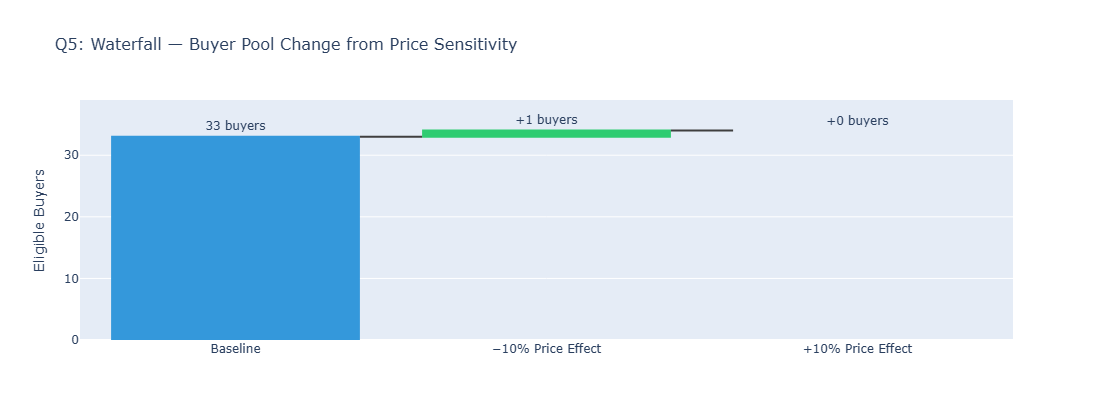

In [7]:
base_count  = int(baseline['adj_affordable'].sum())
minus_count = int(minus_10['adj_affordable'].sum())
plus_count  = int(plus_10['adj_affordable'].sum())

fig3 = go.Figure(go.Waterfall(
    orientation='v',
    measure=['absolute', 'relative', 'relative'],
    x=['Baseline', '−10% Price Effect', '+10% Price Effect'],
    y=[base_count, minus_count - base_count, plus_count - base_count],
    text=[
        f'{base_count} buyers',
        f'{minus_count - base_count:+d} buyers',
        f'{plus_count  - base_count:+d} buyers'
    ],
    textposition='outside',
    connector={'line': {'color': 'rgb(63, 63, 63)'}},
    decreasing={'marker': {'color': '#e74c3c'}},
    increasing={'marker': {'color': '#2ecc71'}},
    totals={'marker': {'color': '#3498db'}}
))

fig3.update_layout(
    title='Q5: Waterfall — Buyer Pool Change from Price Sensitivity',
    yaxis_title='Eligible Buyers',
    height=420,
    title_font_size=16
)
fig3.show()

## 📊 Q5 Findings: Price vs Affordability Sensitivity

### Key Insights

1. **Baseline eligible pool**: 33/60 loan customers (55%) can afford their
   chosen vehicle at current prices under the 40% EMI-to-income threshold.

2. **Price reduction impact (−10%)**: Dropping prices by 10% expands the
   eligible buyer pool by only 1 customer (33→34, 55%→57%). The marginal
   impact is minimal because most ineligible customers are far beyond the
   40% threshold — a 10% price cut is insufficient to cross it.

3. **Price increase impact (+10%)**: A 10% price increase causes zero
   additional buyers to lose eligibility. Customers near the boundary
   have enough income buffer to absorb the increase.

4. **Segment insensitivity**: Every segment shows identical eligibility
   across all three scenarios except Hatchback (+10% gains 1 buyer at
   −10% price). This confirms that price sensitivity is low — the
   binding constraint is income, not price.

5. **Hypercar structural barrier**: Hypercar segment stays at 0%
   eligible across all scenarios. A 10% price reduction on a $3.2M
   Bugatti Chiron ($320K savings) is insufficient to bring EMI within
   40% of any customer's monthly income in this dataset.

6. **Pricing strategy recommendation**: A 10% price reduction is not
   the right lever for CarIQ's affordability problem. The more effective
   interventions are: (a) extending loan tenure from 60 to 84 months
   to reduce monthly EMI, or (b) targeting customers in the $60–120K
   USD income band where affordability is already 85.7%.

### Limitations
- Down-payment ratio held constant across all scenarios
- Interest rates and tenure not adjusted in the sensitivity model
- Sample of 60 loan transactions limits statistical significance
- Real-world price sensitivity would require 500+ transactions minimum